<div style="background:linear-gradient(135deg,#7a3d00 0%,#b45309 55%,#d97706 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#ffe9c7;font-weight:700;text-transform:uppercase">Chapter 14 · Solutions</div>
  <div style="font-size:36px;font-weight:900;line-height:1.1;margin:10px 0 6px">Practice Challenges, Worked Answers ✅</div>
  <div style="font-size:15px;color:#ffe6cc;max-width:700px;line-height:1.6">Full solutions to the five "Charts for Categorical Data" challenges. Try them yourself first, then compare.</div>
  <div style="margin-top:16px;font-size:13px;color:#ffe2bf">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INK="#1a2138"; CYAN="#0891b2"; PURPLE="#7c3aed"; AMBER="#d97706"; GREEN="#059669"; PINK="#db2777"; BLUE="#2563eb"; GRID="#e6e9f2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
print("Ready.")

Ready.


<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0891b2;letter-spacing:1px">CHALLENGE 1 · SORTED BARS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Build the right bar chart</div>
<div style="color:#4a5578;margin-top:6px">From the pet counts below, draw a horizontal bar chart sorted by value. Why is horizontal + sorted a good choice here?</div>
</div>

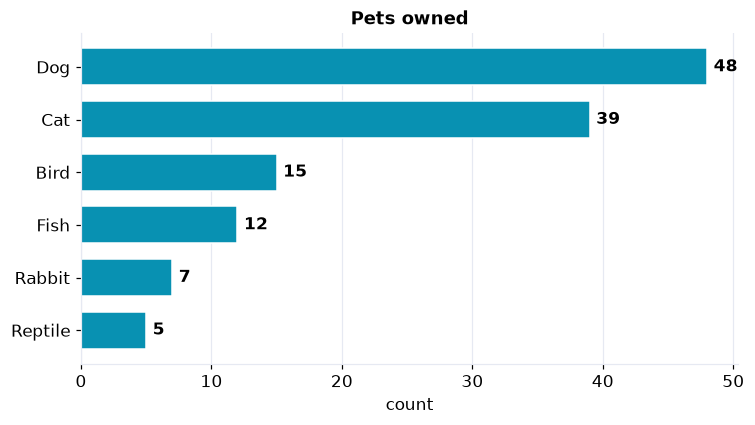

In [2]:
pets = pd.Series({"Dog":48,"Cat":39,"Fish":12,"Rabbit":7,"Reptile":5,"Bird":15})
pets = pets.sort_values()
fig, ax = plt.subplots(figsize=(7,4))
ax.barh(pets.index, pets.values, color=CYAN, edgecolor="white", height=0.7)
ax.set_xlabel("count"); ax.set_title("Pets owned"); ax.grid(axis="y", visible=False)
for i,v in enumerate(pets.values): ax.text(v+0.5, i, str(v), va="center", fontweight="bold")
plt.tight_layout(); plt.show()

**Answer:** Sorting makes the ranking instant, and horizontal bars give each label room without rotating text. These are **nominal** categories (no natural order), so reordering by value is perfectly fair, that would NOT be allowed for ordinal categories like S/M/L/XL.

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#db2777;letter-spacing:1px">CHALLENGE 2 · SPOT THE LIE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Fix a misleading axis</div>
<div style="color:#4a5578;margin-top:6px">A chart compares two satisfaction scores, 82 and 86, with the y-axis starting at 80. Redraw it honestly and quantify how much the truncated axis exaggerates the gap.</div>
</div>

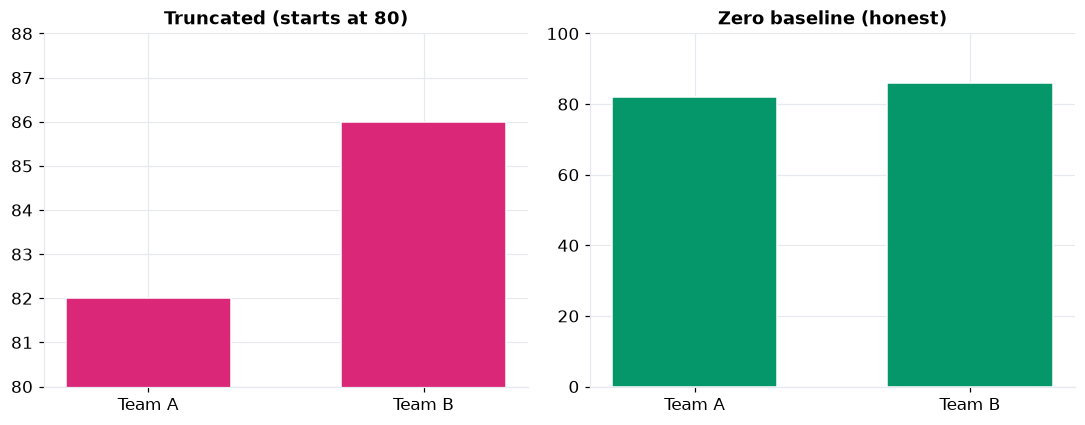

truncated bar heights ratio: 3.0x   |   real ratio: 1.05x


In [3]:
labels=["Team A","Team B"]; vals=[82, 86]
fig,(a1,a2)=plt.subplots(1,2,figsize=(10,4))
a1.bar(labels, vals, color=PINK, edgecolor="white", width=0.6); a1.set_ylim(80,88)
a1.set_title("Truncated (starts at 80)")
a2.bar(labels, vals, color=GREEN, edgecolor="white", width=0.6); a2.set_ylim(0,100)
a2.set_title("Zero baseline (honest)")
plt.tight_layout(); plt.show()
looks=(vals[1]-80)/(vals[0]-80); real=vals[1]/vals[0]
print(f"truncated bar heights ratio: {looks:.1f}x   |   real ratio: {real:.2f}x")

**Answer:** Starting at 80 makes Team B's bar look **3x** Team A's, when the scores really differ by under 5%. Because a bar encodes length from zero, cutting the baseline breaks that proportionality. The honest fix is a **zero baseline** (or, if zero is impractical, switch to a dot plot, which does not require one).

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">CHALLENGE 3 · BAR OR HISTOGRAM?</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Tell them apart</div>
<div style="color:#4a5578;margin-top:6px">For each dataset, say whether you would draw a bar chart or a histogram, and what the visual tell is: (a) counts of favorite ice-cream flavor; (b) the distribution of 500 customers' ages.</div>
</div>

In [4]:
print("(a) favorite flavor  -> BAR CHART  : distinct categories, bars have GAPS, reorderable")
print("(b) ages of 500 people -> HISTOGRAM : continuous values binned, bars TOUCH, fixed order")

(a) favorite flavor  -> BAR CHART  : distinct categories, bars have GAPS, reorderable
(b) ages of 500 people -> HISTOGRAM : continuous values binned, bars TOUCH, fixed order


**Answer:** (a) Flavor is **categorical**, so a **bar chart** with gaps between bars; you may sort them. (b) Age is **continuous**, so a **histogram** of binned ages with **touching** bars along a number line, and the bins stay in numeric order. The touching-vs-gapped bars are the quickest tell.

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#059669;letter-spacing:1px">CHALLENGE 4 · PIE TO BAR</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">When a pie fails</div>
<div style="color:#4a5578;margin-top:6px">A survey of 8 favorite-genre categories is shown as a pie chart and readers cannot rank the middle ones. Convert it to a sorted bar chart and explain why the bar is clearer.</div>
</div>

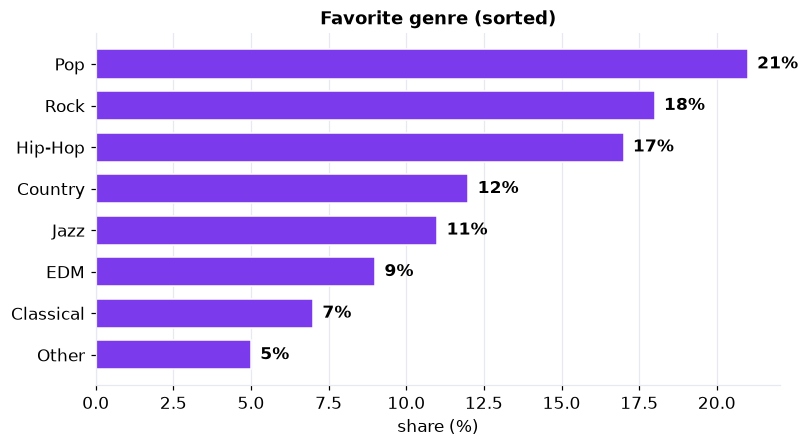

slices sum to 100%


In [5]:
genre = pd.Series({"Pop":21,"Rock":18,"Hip-Hop":17,"Country":12,"Jazz":11,"EDM":9,"Classical":7,"Other":5})
g = genre.sort_values()
fig, ax = plt.subplots(figsize=(7.5,4.2))
ax.barh(g.index, g.values, color=PURPLE, edgecolor="white", height=0.7)
ax.set_xlabel("share (%)"); ax.set_title("Favorite genre (sorted)"); ax.grid(axis="y", visible=False)
for i,v in enumerate(g.values): ax.text(v+0.3, i, f"{v}%", va="center", fontweight="bold")
plt.tight_layout(); plt.show()
print(f"slices sum to {genre.sum()}%")

**Answer:** Eight slices is far too many for a pie, several are near the same size and the eye cannot rank angles that close. On a **sorted bar chart** every value sits on a common scale, so the ranking and the near-ties (Rock 18 vs Hip-Hop 17) are obvious. As a rule, keep pies to about 5 slices at most; otherwise use a bar.

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#2563eb;letter-spacing:1px">CHALLENGE 5 · GROUPED VS STACKED</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Pick the layout for the question</div>
<div style="color:#4a5578;margin-top:6px">You have sales of two product lines across three regions. Make BOTH a grouped and a stacked bar chart, then say which answers "which line sells more in each region?" and which answers "what is each region's total?"</div>
</div>

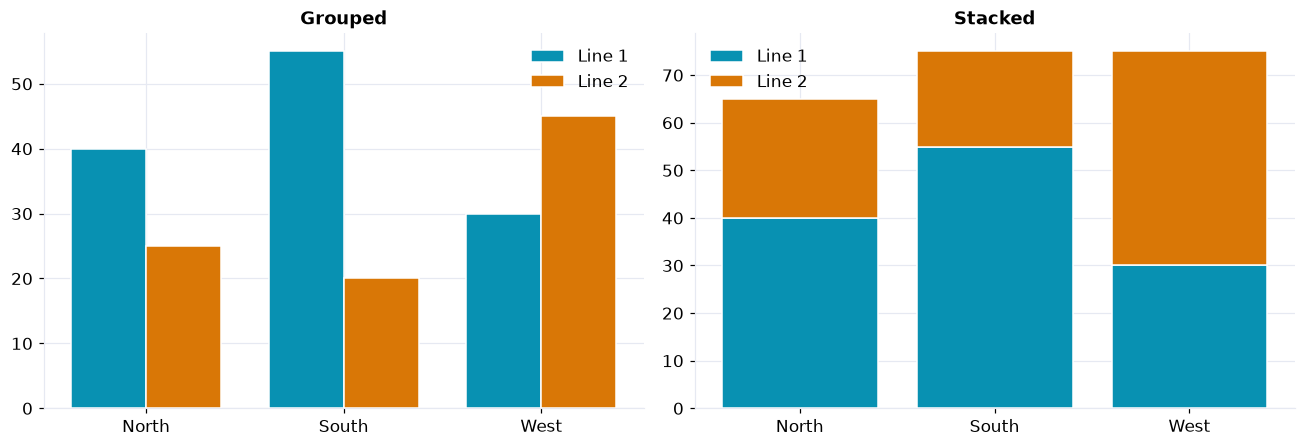

In [6]:
regions=["North","South","West"]; line1=np.array([40,55,30]); line2=np.array([25,20,45])
x=np.arange(3); w=0.38
fig,(a1,a2)=plt.subplots(1,2,figsize=(12,4.2))
a1.bar(x-w/2,line1,w,label="Line 1",color=CYAN,edgecolor="white")
a1.bar(x+w/2,line2,w,label="Line 2",color=AMBER,edgecolor="white")
a1.set_title("Grouped"); a1.set_xticks(x); a1.set_xticklabels(regions); a1.legend()
a2.bar(x,line1,label="Line 1",color=CYAN,edgecolor="white")
a2.bar(x,line2,bottom=line1,label="Line 2",color=AMBER,edgecolor="white")
a2.set_title("Stacked"); a2.set_xticks(x); a2.set_xticklabels(regions); a2.legend()
plt.tight_layout(); plt.show()

**Answer:** The **grouped** chart answers "which line sells more in each region?" because both bars share the zero baseline and compare directly. The **stacked** chart answers "what is each region's total?" because the segments add up to the full height, but the upper (Line 2) segments float, so comparing Line 2 across regions on the stacked chart is hard. Match the layout to the question.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">🎉 Nicely done!</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">You built honest bar charts, exposed a truncated-axis lie, separated bars from histograms, retired an overloaded pie, and matched grouped vs stacked layouts to the question being asked. A chart is an argument, you can now make yours clearly and fairly.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>